# Algo Extraction Sanity Check

Apply algorithmic feature extraction (no LLM) to all 4 disease datasets and inspect feature prevalence rates.

**Expected clinical patterns:**
- **Cholecystitis**: RUQ pain, Murphy's sign, gallstone history, elevated bilirubin/LFTs
- **Pancreatitis**: Epigastric pain radiating to back, alcohol history, elevated lipase, SIRS
- **Diverticulitis**: LLQ pain, bowel habit change, prior diverticular disease
- **Appendicitis**: RLQ pain, migration, RLQ tenderness, anorexia, nausea/vomiting, elevated WBC

In [1]:
import sys, os, csv, copy, warnings
warnings.filterwarnings('ignore')

# Add workspace root to path
ROOT = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

from feature_extraction.algo_extractor import extract_algo_features, extract_radiology_tests
from feature_schema import default_features

print('Imports OK')

Imports OK


In [2]:
DATA_DIR = os.path.join(ROOT, 'raw_data')

DATASETS = {
    'Cholecystitis': 'cholecystitis_hadm_info_first_diag.csv',
    'Pancreatitis':  'pancreatitis_hadm_info_first_diag.csv',
    'Diverticulitis':'diverticulitis_hadm_info_first_diag.csv',
    'Appendicitis':  'appendicitis_hadm_info_first_diag.csv',
}

def run_algo_extraction(csv_path: str) -> list[dict]:
    """Run algo-only extraction on every row; return list of feature dicts."""
    records = []
    with open(csv_path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            feats = default_features()
            feats.update(extract_algo_features(row))
            # Also record imaging modality counts (no LLM, just parsed list)
            rad = extract_radiology_tests(row)
            feats['_n_radiology'] = len(rad)
            feats['_modalities'] = [e['test_key'] for e in rad if e['test_key']]
            feats['_hadm_id'] = row.get('hadm_id', '')
            records.append(feats)
    return records

all_data: dict[str, list[dict]] = {}
for disease, fname in DATASETS.items():
    path = os.path.join(DATA_DIR, fname)
    records = run_algo_extraction(path)
    all_data[disease] = records
    print(f'{disease}: {len(records)} patients')

Cholecystitis: 648 patients


Pancreatitis: 538 patients
Diverticulitis: 257 patients


Appendicitis: 957 patients


In [3]:
# Build a prevalence table: for each boolean feature, show % True per disease

BOOL_FEATURES = [
    # Pain
    'pain_migration_to_RLQ', 'epigastric_radiating_to_back',
    'bowel_habit_change', 'symptom_duration_over_72h',
    # HPI symptoms
    'anorexia', 'nausea_vomiting', 'alcohol_history',
    'gallstone_history', 'prior_diverticular_disease',
    # PE signs
    'murphys_sign', 'RLQ_tenderness', 'rebound_tenderness',
    'RUQ_mass', 'peritoneal_signs', 'impaired_mental_status',
    # Vitals
    'fever_temp_ge_37_3', 'fever_temp_ge_38',
    # Labs
    'WBC_gt_10k', 'WBC_gt_18k', 'left_shift',
    'CRP_elevated', 'CRP_gt_200',
    'lipase_ge_3xULN', 'BUN_gt_25',
    'bilirubin_elevated', 'LFTs_elevated', 'creatinine_elevated',
    'beta_hCG_positive', 'SIRS_criteria_ge_2',
    # Demographics
    'age_gt_60', 'is_female_reproductive_age',
    # Organ dysfunction
    'has_organ_dysfunction',
]

diseases = list(all_data.keys())
prevalence = {}
for feat in BOOL_FEATURES:
    row_vals = {}
    for disease, records in all_data.items():
        vals = [r[feat] for r in records]
        row_vals[disease] = 100.0 * sum(vals) / len(vals)
    prevalence[feat] = row_vals

df_prev = pd.DataFrame(prevalence).T
df_prev.index.name = 'Feature'
df_prev = df_prev[diseases]  # consistent column order

pd.set_option('display.float_format', '{:.1f}%'.format)
print(df_prev.to_string())

                              Cholecystitis  Pancreatitis  Diverticulitis  Appendicitis
Feature                                                                                
pain_migration_to_RLQ                  0.2%          0.0%            1.2%          8.8%
epigastric_radiating_to_back           8.2%         17.5%            1.2%          1.0%
bowel_habit_change                    47.7%         60.4%           63.0%         58.8%
symptom_duration_over_72h             45.2%         54.3%           51.8%         26.6%
anorexia                              10.8%         13.0%           16.0%         30.2%
nausea_vomiting                       69.9%         78.1%           43.6%         65.4%
alcohol_history                        5.1%         16.2%            5.4%          2.5%
gallstone_history                     26.4%         20.8%            2.7%          1.5%
prior_diverticular_disease             4.6%          6.1%           23.0%          3.1%
murphys_sign                    

In [4]:
# Pain location distribution per disease

from collections import Counter

print('=== Pain Location Distribution (%) ===\n')
for disease, records in all_data.items():
    locs = [r['pain_location'] for r in records]
    counter = Counter(locs)
    total = len(locs)
    print(f'{disease} (n={total}):')
    for loc, cnt in counter.most_common():
        print(f'  {loc:25s}: {cnt:4d} ({100*cnt/total:.1f}%)')
    print()

=== Pain Location Distribution (%) ===

Cholecystitis (n=648):
  RUQ                      :  440 (67.9%)
  Other                    :  112 (17.3%)
  Epigastric               :   75 (11.6%)
  General_Abdomen          :    7 (1.1%)
  RLQ                      :    5 (0.8%)
  LUQ                      :    4 (0.6%)
  Periumbilical            :    3 (0.5%)
  LLQ                      :    2 (0.3%)

Pancreatitis (n=538):
  RUQ                      :  204 (37.9%)
  Epigastric               :  168 (31.2%)
  Other                    :  115 (21.4%)
  General_Abdomen          :   18 (3.3%)
  LLQ                      :   11 (2.0%)
  LUQ                      :   10 (1.9%)
  Periumbilical            :    5 (0.9%)
  RLQ                      :    4 (0.7%)
  Pelvic                   :    3 (0.6%)

Diverticulitis (n=257):
  Other                    :  108 (42.0%)
  LLQ                      :   62 (24.1%)
  RLQ                      :   39 (15.2%)
  Pelvic                   :   17 (6.6%)
  General_Abdomen  

In [5]:
# Radiology modality distribution per disease

print('=== Radiology Modalities (% of patients with ≥1 report of this type) ===\n')
modality_names = ['Lab_Panel', 'Ultrasound_Abdomen', 'CT_Abdomen',
                  'HIDA_Scan', 'MRCP_Abdomen', 'Radiograph_Chest', 'MRI_Abdomen']
for disease, records in all_data.items():
    total = len(records)
    print(f'{disease} (n={total}):')
    print(f'  Avg radiology reports per patient: {np.mean([r["_n_radiology"] for r in records]):.2f}')
    mod_counts = Counter(m for r in records for m in r['_modalities'])
    for mod in modality_names:
        cnt = mod_counts.get(mod, 0)
        print(f'  {mod:25s}: {cnt:4d} ({100*cnt/total:.1f}%)')
    print()

=== Radiology Modalities (% of patients with ≥1 report of this type) ===

Cholecystitis (n=648):
  Avg radiology reports per patient: 2.60
  Lab_Panel                :    0 (0.0%)
  Ultrasound_Abdomen       :  619 (95.5%)
  CT_Abdomen               :  345 (53.2%)
  HIDA_Scan                :    0 (0.0%)
  MRCP_Abdomen             :   88 (13.6%)
  Radiograph_Chest         :  503 (77.6%)
  MRI_Abdomen              :   13 (2.0%)

Pancreatitis (n=538):
  Avg radiology reports per patient: 3.42
  Lab_Panel                :    0 (0.0%)
  Ultrasound_Abdomen       :  442 (82.2%)
  CT_Abdomen               :  387 (71.9%)
  HIDA_Scan                :    0 (0.0%)
  MRCP_Abdomen             :  136 (25.3%)
  Radiograph_Chest         :  654 (121.6%)
  MRI_Abdomen              :   23 (4.3%)

Diverticulitis (n=257):
  Avg radiology reports per patient: 3.01
  Lab_Panel                :    0 (0.0%)
  Ultrasound_Abdomen       :   62 (24.1%)
  CT_Abdomen               :  337 (131.1%)
  HIDA_Scan         

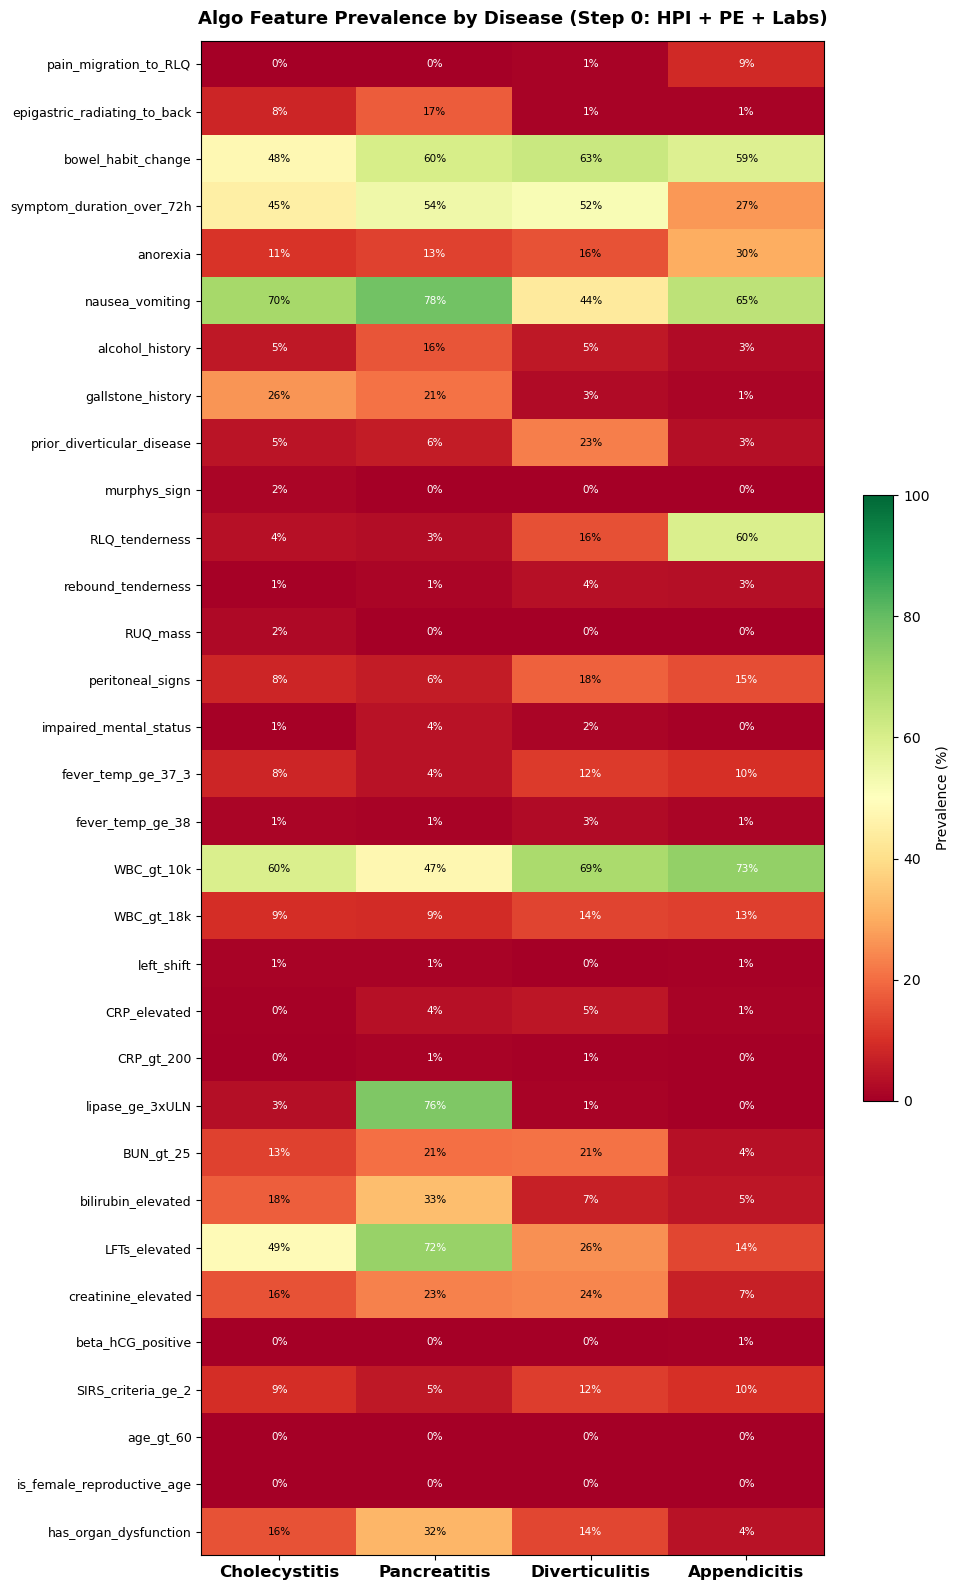

Saved: algo_feature_heatmap.png


In [6]:
# ── Heatmap: feature prevalence across all 4 diseases ──

fig, ax = plt.subplots(figsize=(10, 16))

data_mat = df_prev.values  # shape (n_features, n_diseases)
im = ax.imshow(data_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)

ax.set_xticks(range(len(diseases)))
ax.set_xticklabels(diseases, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(BOOL_FEATURES)))
ax.set_yticklabels(BOOL_FEATURES, fontsize=9)

# Annotate cells
for i in range(len(BOOL_FEATURES)):
    for j in range(len(diseases)):
        val = data_mat[i, j]
        color = 'white' if val > 70 or val < 15 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=7.5, color=color)

plt.colorbar(im, ax=ax, label='Prevalence (%)', shrink=0.4)
ax.set_title('Algo Feature Prevalence by Disease (Step 0: HPI + PE + Labs)', 
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('algo_feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: algo_feature_heatmap.png')

In [7]:
# ── Clinical sanity checks — expected high/low prevalence per disease ──

SANITY_CHECKS = [
    # (disease, feature, direction, threshold, description)
    # Cholecystitis
    ('Cholecystitis', 'murphys_sign',      'high', 20, "Murphy's sign in chole (expect ≥20%)"),
    ('Cholecystitis', 'gallstone_history', 'high', 10, 'Gallstone hx in chole (expect ≥10%)'),
    ('Cholecystitis', 'LFTs_elevated',     'high', 25, 'Elevated LFTs in chole (expect ≥25%)'),
    ('Cholecystitis', 'lipase_ge_3xULN',   'low',  20, 'Lipase 3xULN in chole (expect <20%)'),
    # Pancreatitis
    ('Pancreatitis',  'lipase_ge_3xULN',       'high', 40, 'Lipase 3xULN in pancreatitis (expect ≥40%)'),
    ('Pancreatitis',  'epigastric_radiating_to_back', 'high', 10, 'Epigastric-to-back radiation in pancreatitis (expect ≥10%)'),
    ('Pancreatitis',  'alcohol_history',       'high',  5, 'Alcohol hx in pancreatitis (expect ≥5%)'),
    ('Pancreatitis',  'nausea_vomiting',       'high', 30, 'N/V in pancreatitis (expect ≥30%)'),
    ('Pancreatitis',  'murphys_sign',           'low', 30, "Murphy's sign in pancreatitis (expect <30%)"),
    # Diverticulitis
    ('Diverticulitis','bowel_habit_change',     'high', 10, 'Bowel habit change in diver (expect ≥10%)'),
    ('Diverticulitis','prior_diverticular_disease','high', 5, 'Prior diver disease in diver (expect ≥5%)'),
    ('Diverticulitis','lipase_ge_3xULN',        'low',  20, 'Lipase 3xULN in diver (expect <20%)'),
    # Appendicitis
    ('Appendicitis',  'RLQ_tenderness',     'high', 30, 'RLQ tenderness in appendicitis (expect ≥30%)'),
    ('Appendicitis',  'anorexia',           'high', 10, 'Anorexia in appendicitis (expect ≥10%)'),
    ('Appendicitis',  'pain_migration_to_RLQ','high', 5, 'Pain migration to RLQ (expect ≥5%)'),
    ('Appendicitis',  'WBC_gt_10k',         'high', 30, 'WBC>10k in appendicitis (expect ≥30%)'),
    ('Appendicitis',  'lipase_ge_3xULN',    'low',  20, 'Lipase 3xULN in appendicitis (expect <20%)'),
]

print('=== Clinical Sanity Checks ===\n')
passed = failed = 0
for disease, feat, direction, threshold, desc in SANITY_CHECKS:
    records = all_data[disease]
    pct = 100.0 * sum(r[feat] for r in records) / len(records)
    if direction == 'high':
        ok = pct >= threshold
    else:
        ok = pct < threshold
    status = '✓ PASS' if ok else '✗ FAIL'
    if ok:
        passed += 1
    else:
        failed += 1
    print(f'{status}  {desc}')
    print(f'       Actual: {pct:.1f}%  (threshold: {direction} {threshold}%)')
    print()

print(f'Summary: {passed} passed, {failed} failed out of {passed+failed} checks')

=== Clinical Sanity Checks ===

✗ FAIL  Murphy's sign in chole (expect ≥20%)
       Actual: 1.5%  (threshold: high 20%)

✓ PASS  Gallstone hx in chole (expect ≥10%)
       Actual: 26.4%  (threshold: high 10%)

✓ PASS  Elevated LFTs in chole (expect ≥25%)
       Actual: 48.8%  (threshold: high 25%)

✓ PASS  Lipase 3xULN in chole (expect <20%)
       Actual: 3.4%  (threshold: low 20%)

✓ PASS  Lipase 3xULN in pancreatitis (expect ≥40%)
       Actual: 76.0%  (threshold: high 40%)

✓ PASS  Epigastric-to-back radiation in pancreatitis (expect ≥10%)
       Actual: 17.5%  (threshold: high 10%)

✓ PASS  Alcohol hx in pancreatitis (expect ≥5%)
       Actual: 16.2%  (threshold: high 5%)

✓ PASS  N/V in pancreatitis (expect ≥30%)
       Actual: 78.1%  (threshold: high 30%)

✓ PASS  Murphy's sign in pancreatitis (expect <30%)
       Actual: 0.4%  (threshold: low 30%)

✓ PASS  Bowel habit change in diver (expect ≥10%)
       Actual: 63.0%  (threshold: high 10%)

✓ PASS  Prior diver disease in diver

In [8]:
# ── Feature extraction rate: how many patients have each field populated ──
# (i.e. not missing / default False) — helps spot data quality issues

# For boolean features: how many have at least ONE True across any key group per patient
GROUP_CHECKS = {
    'Any HPI extracted': ['pain_migration_to_RLQ','epigastric_radiating_to_back',
                          'bowel_habit_change','anorexia','nausea_vomiting',
                          'alcohol_history','gallstone_history','prior_diverticular_disease'],
    'Any PE sign extracted': ['murphys_sign','RLQ_tenderness','rebound_tenderness',
                              'peritoneal_signs','impaired_mental_status'],
    'Has fever (≥37.3°C)': ['fever_temp_ge_37_3','fever_temp_ge_38'],
    'Any lab result extracted': ['WBC_gt_10k','lipase_ge_3xULN','BUN_gt_25',
                                 'bilirubin_elevated','LFTs_elevated','CRP_elevated',
                                 'creatinine_elevated'],
    'SIRS positive': ['SIRS_criteria_ge_2'],
}

print('=== Data Coverage: % patients with ≥1 positive signal in each group ===\n')
print(f'{"Group":<40}', '  '.join(f'{d[:12]:>12}' for d in diseases))
print('-' * 90)
for group_name, feats in GROUP_CHECKS.items():
    row_vals = []
    for disease, records in all_data.items():
        has_any = sum(1 for r in records if any(r.get(f, False) for f in feats))
        row_vals.append(f'{100*has_any/len(records):>11.1f}%')
    print(f'{group_name:<40}', '  '.join(row_vals))

print()

# Correct temp extraction rate: use _extract_temp_f directly, not fever flags
# NOTE: "fever_temp_ge_37_3 = False" does NOT mean temp was missing —
#       it may just mean the extracted temp was normal (<37.3°C).
from feature_extraction.algo_extractor import _extract_temp_f
import csv as csv_mod

print('=== Temperature extraction rate (% with ANY temp value parsed from PE) ===\n')
for disease, fname in DATASETS.items():
    path = os.path.join(DATA_DIR, fname)
    n_total = n_extracted = 0
    with open(path, newline='', encoding='utf-8') as f:
        for row in csv_mod.DictReader(f):
            n_total += 1
            if _extract_temp_f(str(row.get('Physical Examination', '') or '')) is not None:
                n_extracted += 1
    print(f'  {disease}: {n_extracted}/{n_total} = {100*n_extracted/n_total:.1f}% have temp extracted')

print()

# Sex extraction from HPI text (MIMIC redacts ages as "___", but sex is recoverable)
import re as re_mod
print('=== Sex inference from HPI text (MIMIC age is always redacted as "___") ===\n')
for disease, fname in DATASETS.items():
    path = os.path.join(DATA_DIR, fname)
    counts = {'F': 0, 'M': 0, 'unknown': 0}
    n_total = 0
    with open(path, newline='', encoding='utf-8') as f:
        for row in csv_mod.DictReader(f):
            n_total += 1
            hpi = str(row.get('Patient History', '') or '')
            if re_mod.search(r'\bfemale\b|\bwoman\b|\bshe\b|\bher\b', hpi, re_mod.I):
                counts['F'] += 1
            elif re_mod.search(r'\bmale\b|\bman\b|\bhe\b|\bhis\b', hpi, re_mod.I):
                counts['M'] += 1
            else:
                counts['unknown'] += 1
    print(f'  {disease} (n={n_total}): F={counts["F"]} ({100*counts["F"]/n_total:.1f}%), '
          f'M={counts["M"]} ({100*counts["M"]/n_total:.1f}%), '
          f'unknown={counts["unknown"]} ({100*counts["unknown"]/n_total:.1f}%)')
print()
print('NOTE: age_gt_60 and is_female_reproductive_age are always False in MIMIC')
print('      because MIMIC-IV redacts all patient ages as "___" in note text.')
print('      The age field cannot be recovered by any text-based method (algo or LLM).')

=== Data Coverage: % patients with ≥1 positive signal in each group ===

Group                                    Cholecystiti  Pancreatitis  Diverticulit  Appendicitis
------------------------------------------------------------------------------------------
Any HPI extracted                               89.2%         92.0%         84.0%         91.4%
Any PE sign extracted                           13.6%         13.4%         32.3%         62.8%
Fever extracted (temp)                           8.0%          4.1%         12.1%          9.8%
Any lab result extracted                        83.8%         95.5%         86.8%         78.0%
SIRS computable                                  9.4%          5.4%         12.5%         10.0%

=== Missingness: % patients where temp could NOT be extracted ===

  Cholecystitis: 92.0% have no temp extracted
  Pancreatitis: 95.9% have no temp extracted
  Diverticulitis: 87.9% have no temp extracted
  Appendicitis: 90.2% have no temp extracted


In [9]:
# ── Spot-check: show a few raw records vs extracted features for each disease ──

import json, csv as csv_mod

def show_spot_check(disease: str, n: int = 2):
    fname = DATASETS[disease]
    path = os.path.join(DATA_DIR, fname)
    with open(path, newline='', encoding='utf-8') as f:
        reader = csv_mod.DictReader(f)
        rows = [next(reader) for _ in range(n)]
    
    KEY_FEATURES = [
        'pain_location', 'murphys_sign', 'RLQ_tenderness', 'epigastric_radiating_to_back',
        'bowel_habit_change', 'pain_migration_to_RLQ', 'nausea_vomiting', 'anorexia',
        'gallstone_history', 'alcohol_history', 'prior_diverticular_disease',
        'WBC_gt_10k', 'lipase_ge_3xULN', 'LFTs_elevated', 'bilirubin_elevated',
        'fever_temp_ge_38', 'SIRS_criteria_ge_2', 'age_gt_60',
    ]
    
    for i, row in enumerate(rows):
        feats = default_features()
        feats.update(extract_algo_features(row))
        
        print(f'\n{"="*70}')
        print(f'{disease} — Patient {i+1}  (hadm_id={row.get("hadm_id", "?")})')
        print(f'{"="*70}')
        print('\n[Patient History (first 400 chars)]')
        print(row.get('Patient History', '')[:400])
        print('\n[Physical Examination (first 300 chars)]')
        print(row.get('Physical Examination', '')[:300])
        print('\n[Extracted Features]')
        for k in KEY_FEATURES:
            v = feats[k]
            marker = ' ◄' if v is True else ''
            print(f'  {k:<40}: {v}{marker}')

for disease in diseases:
    show_spot_check(disease, n=2)


Cholecystitis — Patient 1  (hadm_id=29897948)

[Patient History (first 400 chars)]
___ w/h/o HTN, hysterectomy, hypothyroidism p/w abdominal pain.  She noted the abdominal pain started suddenly yesterday evening  worsening over the course of the day. + nausea and vomiting,  bilious x1.  Normal BM this AM, no diarrhea/constipation.  No  dysuria/hematuria.  No fevers.    Past Medical History: PMH: HTN  PSH: supracervical hysterectomy, PDA ligation @3, thyroidectomy    Social Histo

[Physical Examination (first 300 chars)]
On admission: Vitals: 98.8 73 153/99 15 100% RA  GEN: NAD CV: RRR ABD: TTP RUQ, otherwise soft. EXT: no c/c/e

[Extracted Features]
  pain_location                           : Other
  murphys_sign                            : False
  RLQ_tenderness                          : False
  epigastric_radiating_to_back            : False
  bowel_habit_change                      : True ◄
  pain_migration_to_RLQ                   : False
  nausea_vomiting                       